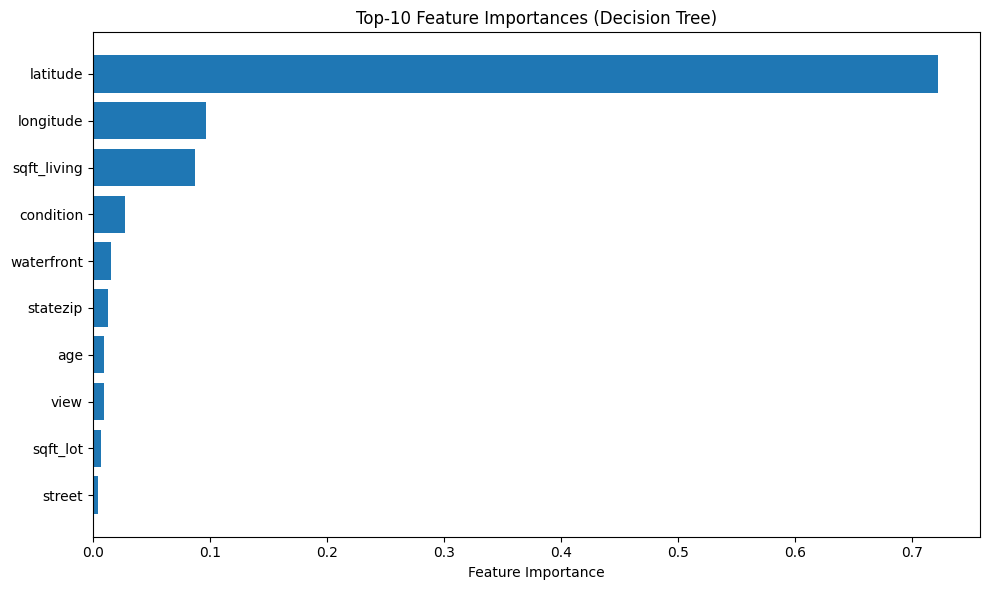

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

path = os.path.dirname(os.getcwd())
if path not in sys.path:
    sys.path.insert(0, path)


def plot_feature_importance(model_path: str, top_n: int = 10):
    state = torch.load(model_path, weights_only=False)
    tree = state["tree"]

    importances = tree.feature_importances_
    feature_names = tree.feature_names_in_

    indices = np.argsort(importances)[::-1][:top_n]
    top_names = feature_names[indices]
    top_importances = importances[indices]

    _, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(top_n - 1, -1, -1), top_importances, align="center")
    ax.set_yticks(range(top_n - 1, -1, -1))
    ax.set_yticklabels(top_names)
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top-{top_n} Feature Importances (Decision Tree)")
    plt.tight_layout()
    plt.show()


model_path = os.path.join(path, "models", "best_models", "best_dt.pth")
plot_feature_importance(model_path)